In [2]:
!git clone https://github.com/sohamjadhav95/ML4Sci-DeepLense-GSoC2026.git

Cloning into 'ML4Sci-DeepLense-GSoC2026'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.


In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
zip_path = "/content/drive/MyDrive/Projects/ML4Sci Test Projects/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted. Folder structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} files')

Extracted. Folder structure:
dataset/
  0 files
  __MACOSX/
    0 files
    dataset/
      val/
      train/
  dataset/
    1 files
    val/
      no/
      vort/
      sphere/
    train/
      no/
      vort/
      sphere/


In [5]:
data_dir = "/content/dataset/dataset"

class_names = ['no', 'vort', 'sphere']
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

class LensDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.transform = transform
        self.samples = []

        split_dir = os.path.join(root_dir, split)
        for cls in class_names:
            cls_dir = os.path.join(split_dir, cls)
            for img_file in os.listdir(cls_dir):
                if img_file.endswith('.npy'):
                    self.samples.append((os.path.join(cls_dir, img_file), class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = np.load(img_path)        # shape: (1, 150, 150)
        img = img.squeeze(0)           # shape: (150, 150)
        img = (img * 255).astype(np.uint8)  # convert to uint8

        img = Image.fromarray(img).convert('RGB')  # grayscale -> RGB for ResNet

        if self.transform:
            img = self.transform(img)
        return img, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = LensDataset(data_dir, 'train', transform=train_transform)
val_dataset = LensDataset(data_dir, 'val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Train samples: 30000
Val samples: 7500


In [7]:
model = models.resnet18(pretrained=True)

# replace final layer for 3 classes
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Linear(in_features=512, out_features=3, bias=True)


In [8]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# train for 10 epochs
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.0260 Acc: 0.4434 | Val Loss: 1.1904 Acc: 0.5103
Epoch 2/10 | Train Loss: 0.5547 Acc: 0.7751 | Val Loss: 0.4501 Acc: 0.8320
Epoch 3/10 | Train Loss: 0.4023 Acc: 0.8449 | Val Loss: 0.4143 Acc: 0.8515
Epoch 4/10 | Train Loss: 0.3540 Acc: 0.8667 | Val Loss: 0.2869 Acc: 0.8983
Epoch 5/10 | Train Loss: 0.3183 Acc: 0.8841 | Val Loss: 0.3149 Acc: 0.8831
Epoch 6/10 | Train Loss: 0.2928 Acc: 0.8911 | Val Loss: 0.2296 Acc: 0.9127
Epoch 7/10 | Train Loss: 0.2692 Acc: 0.9039 | Val Loss: 0.2319 Acc: 0.9187
Epoch 8/10 | Train Loss: 0.2557 Acc: 0.9067 | Val Loss: 0.2476 Acc: 0.9128
Epoch 9/10 | Train Loss: 0.2375 Acc: 0.9131 | Val Loss: 0.2156 Acc: 0.9229
Epoch 10/10 | Train Loss: 0.2277 Acc: 0.9177 | Val Loss: 0.2089 Acc: 0.9256


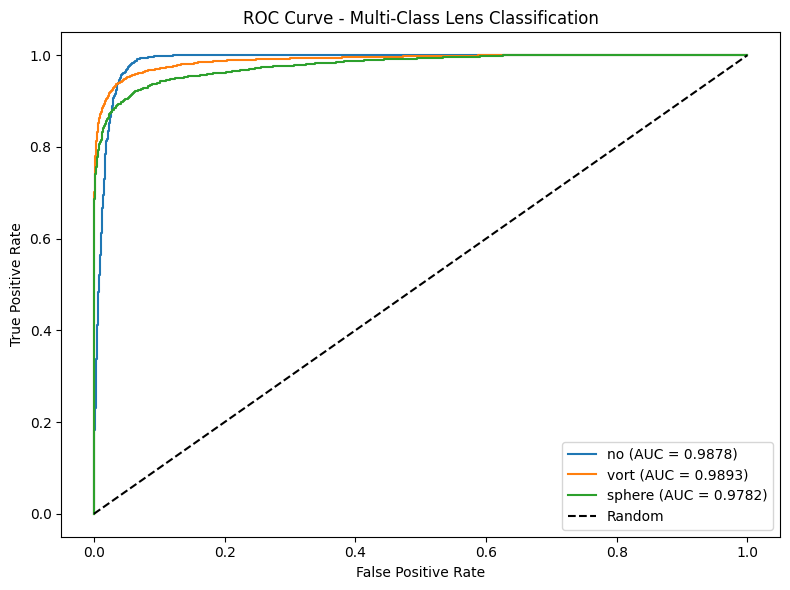


Macro Average AUC: 0.9851


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# collect all predictions on val set
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# binarize labels for one-vs-rest ROC
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# compute ROC and AUC per class
plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-Class Lens Classification')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_test1.png', dpi=150)
plt.show()

# macro average AUC
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(all_labels_bin, all_probs, average='macro')
print(f"\nMacro Average AUC: {macro_auc:.4f}")

In [ ]:
save_path = "/content/ML4Sci-DeepLense-GSoC2026/Test_I_MultiClass_Classification/resnet18_test1.pth"
torch.save(model.state_dict(), save_path)
print("Model saved.")

Model saved.
